=== First 5 rows ===
   RaceEth  HowOldAreYou  WhatIsYourSex  InWhatGradeAreYou  \
0      7.0           4.0            2.0                2.0   
1      5.0           7.0            2.0                2.0   
2      NaN           NaN            2.0                NaN   
3      7.0           1.0            1.0                1.0   
4      7.0           1.0            1.0                5.0   

   AreYouHispanicOrLatino WhatIsYourRace  HowTallAreYouWithoutShoesInMeters  \
0                     1.0              C                                NaN   
1                     2.0              E                               1.70   
2                     NaN            NaN                                NaN   
3                     1.0              A                               1.63   
4                     1.0              B                                NaN   

   HowMuchDoYouWeighWithoutShoesInKG  BicyleHelmetUse  SeatBeltUse  ...  \
0                                NaN              2.0   

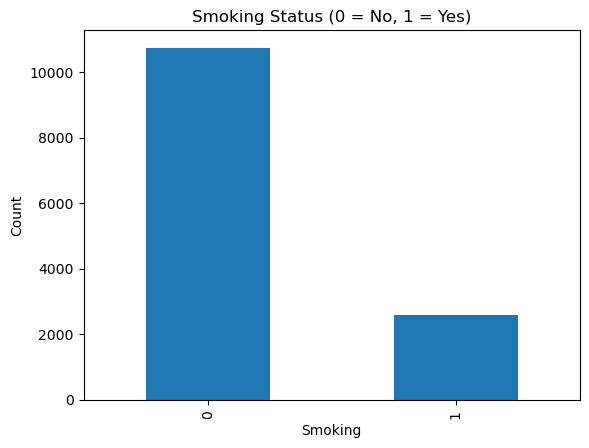


=== Height Summary ===
count    13062.000000
mean         1.694038
std          0.101466
min          1.270000
25%          1.630000
50%          1.680000
75%          1.780000
max          2.110000
Name: HowTallAreYouWithoutShoesInMeters, dtype: float64


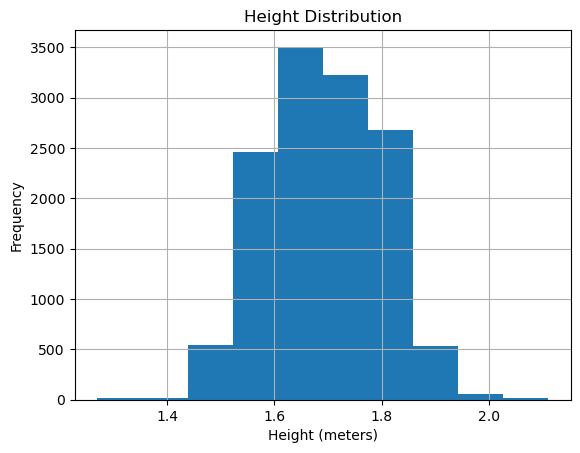

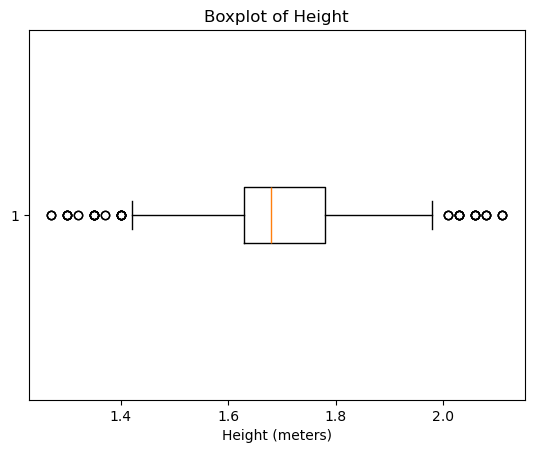

In [4]:
# Week A - Data Check + EDA
# Author: Your Group
# Course: Statistics 2 Practice

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("YRBS_2007.csv")

# 2. Preview data
print("=== First 5 rows ===")
print(df.head())

print("\n=== Data Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Smoking 原始次數分配 (含 NaN) ===")
print(df["CurrentCigaretteUse"].value_counts(dropna=False).sort_index())
# 3. Recode variable (Smoking)
def recode_smoking(x):
    if pd.isna(x):
        return pd.NA
    elif x in [2, 3, 4, 5, 6, 7]:
        return 1
    elif x == 1:
        return 0
    else:
        return pd.NA

df["Smoking_binary"] = df["CurrentCigaretteUse"].apply(recode_smoking)

# 4. Clean data
df_smoke = df["Smoking_binary"].dropna()
df_height = df["HowTallAreYouWithoutShoesInMeters"].dropna()

print("\n=== Sample Sizes ===")
print("Smoking:", len(df_smoke))
print("Height:", len(df_height))

# 5. Smoking EDA
print("\n=== Smoking Distribution ===")
print(df_smoke.value_counts())
print(df_smoke.value_counts(normalize=True))

plt.figure()
df_smoke.value_counts().plot(kind="bar")
plt.title("Smoking Status (0 = No, 1 = Yes)")
plt.xlabel("Smoking")
plt.ylabel("Count")
plt.show()

# 6. Height EDA
print("\n=== Height Summary ===")
print(df_height.describe())

plt.figure()
df_height.hist()
plt.title("Height Distribution")
plt.xlabel("Height (meters)")
plt.ylabel("Frequency")
plt.show()
plt.figure()
plt.boxplot(df_height, vert=False)
plt.title("Boxplot of Height")
plt.xlabel("Height (meters)")
plt.show()


=== Dataset shape ===
(14041, 103)

=== Research Questions ===
1. Is the proportion of students who currently smoke different from 0.20?
2. Is the mean height of students different from 1.70 meters?

=== CurrentCigaretteUse original frequencies ===
CurrentCigaretteUse
1.0    10734
2.0      753
3.0      375
4.0      250
5.0      295
6.0      229
7.0      687
Name: count, dtype: int64

=== Recoded smoking variable ===
CurrentCigaretteUse_Bin
0    10734
1     2589
Name: count, dtype: int64

=== Recoded smoking proportions ===
CurrentCigaretteUse_Bin
0    0.805674
1    0.194326
Name: proportion, dtype: float64

=== Height sample size ===
13062

=== Height summary statistics ===
count    13062.000000
mean         1.694038
std          0.101466
min          1.270000
25%          1.630000
50%          1.680000
75%          1.780000
max          2.110000
Name: HowTallAreYouWithoutShoesInMeters, dtype: float64


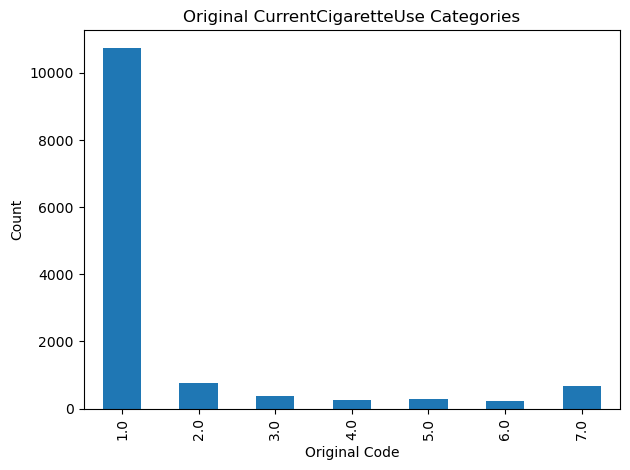

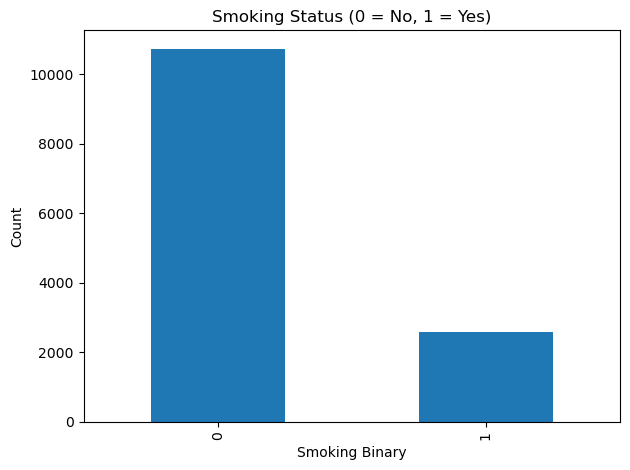

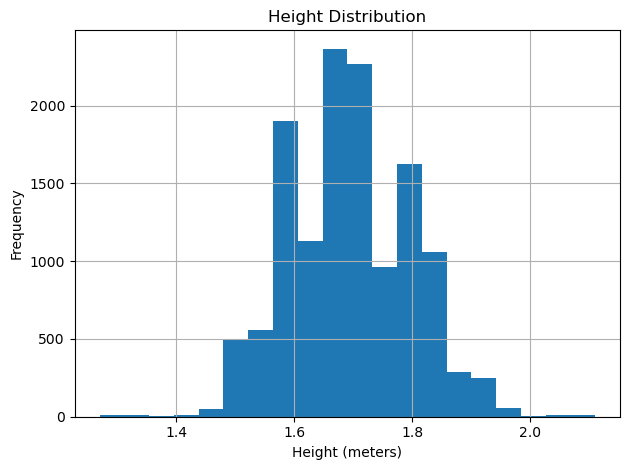

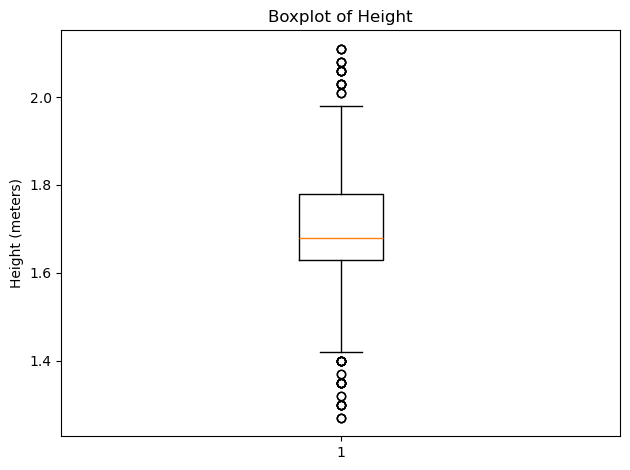


================ PROPORTION ANALYSIS ================
Sample size n = 13323
Number of successes x = 2589
Sample proportion p-hat = 0.194326
95% CI for population proportion = (0.187607, 0.201044)
Null hypothesis: p = 0.2
Alternative hypothesis: p != 0.2
z statistic = -1.637423
p-value = 0.101542
Decision: Fail to reject H0

================ MEAN ANALYSIS ================
Sample size n = 13062
Sample mean x-bar = 1.694038
Sample standard deviation s = 0.101466
95% CI for population mean = (1.692297, 1.695778)
Null hypothesis: mu = 1.7
Alternative hypothesis: mu != 1.7
t statistic = -6.715846
p-value = 0.000000000019
Decision: Reject H0

================ INTERPRETATION ================
Proportion result:
The estimated proportion of students who currently smoke is about 19.43%.
The 95% confidence interval is (18.76%, 20.10%).
At the 5% significance level, there is not enough evidence to say the smoking proportion is different from 20%.

Mean result:
The estimated mean height is about 1.6

In [3]:
# Week B - Inference + Interpretation
# Group Project Cycle 2
# Variables:
# 1) CurrentCigaretteUse -> population proportion test
# 2) HowTallAreYouWithoutShoesInMeters -> population mean test

import math
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ================================
# 1. Load data
# ================================
df = pd.read_csv("YRBS_2007.csv")

print("=== Dataset shape ===")
print(df.shape)

# ================================
# 2. Research questions
# ================================
print("\n=== Research Questions ===")
print("1. Is the proportion of students who currently smoke different from 0.20?")
print("2. Is the mean height of students different from 1.70 meters?")

# ================================
# 3. Variable definition and cleaning
# ================================
# Proportion variable: CurrentCigaretteUse
# failure = code 1
# success = codes 2-7

def recode_smoking(x):
    if pd.isna(x):
        return pd.NA
    elif x in [2, 3, 4, 5, 6, 7]:
        return 1
    elif x == 1:
        return 0
    else:
        return pd.NA

df["CurrentCigaretteUse_Bin"] = df["CurrentCigaretteUse"].apply(recode_smoking)
smoke_bin = df["CurrentCigaretteUse_Bin"].dropna()

print("\n=== CurrentCigaretteUse original frequencies ===")
print(smoke_raw.value_counts().sort_index())

print("\n=== Recoded smoking variable ===")
print(smoke_bin.value_counts().sort_index())
print("\n=== Recoded smoking proportions ===")
print(smoke_bin.value_counts(normalize=True).sort_index())

# Continuous variable: Height
height = df["HowTallAreYouWithoutShoesInMeters"].dropna()

print("\n=== Height sample size ===")
print(len(height))

print("\n=== Height summary statistics ===")
print(height.describe())

# ================================
# 4. EDA
# ================================
plt.figure()
smoke_raw.value_counts().sort_index().plot(kind="bar")
plt.title("Original CurrentCigaretteUse Categories")
plt.xlabel("Original Code")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure()
smoke_bin.value_counts().sort_index().plot(kind="bar")
plt.title("Smoking Status (0 = No, 1 = Yes)")
plt.xlabel("Smoking Binary")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure()
height.hist(bins=20)
plt.title("Height Distribution")
plt.xlabel("Height (meters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure()
plt.boxplot(height, vert=True)
plt.title("Boxplot of Height")
plt.ylabel("Height (meters)")
plt.tight_layout()
plt.show()

# ================================
# 5. Inference for proportion
# ================================
p0 = 0.20
n_p = len(smoke_bin)
x = int(smoke_bin.sum())
phat = x / n_p

z_critical = stats.norm.ppf(0.975)
se_phat = math.sqrt(phat * (1 - phat) / n_p)
ci_prop = (
    phat - z_critical * se_phat,
    phat + z_critical * se_phat
)

se0 = math.sqrt(p0 * (1 - p0) / n_p)
z_stat = (phat - p0) / se0
p_value_prop = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("\n================ PROPORTION ANALYSIS ================")
print(f"Sample size n = {n_p}")
print(f"Number of successes x = {x}")
print(f"Sample proportion p-hat = {phat:.6f}")
print(f"95% CI for population proportion = ({ci_prop[0]:.6f}, {ci_prop[1]:.6f})")
print(f"Null hypothesis: p = {p0}")
print(f"Alternative hypothesis: p != {p0}")
print(f"z statistic = {z_stat:.6f}")
print(f"p-value = {p_value_prop:.6f}")

if p_value_prop < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

# ================================
# 6. Inference for mean
# ================================
mu0 = 1.70
n_m = len(height)
xbar = height.mean()
s = height.std(ddof=1)
se_mean = s / math.sqrt(n_m)

t_critical = stats.t.ppf(0.975, df=n_m - 1)
ci_mean = (
    xbar - t_critical * se_mean,
    xbar + t_critical * se_mean
)

t_stat = (xbar - mu0) / se_mean
p_value_mean = 2 * (1 - stats.t.cdf(abs(t_stat), df=n_m - 1))

print("\n================ MEAN ANALYSIS ================")
print(f"Sample size n = {n_m}")
print(f"Sample mean x-bar = {xbar:.6f}")
print(f"Sample standard deviation s = {s:.6f}")
print(f"95% CI for population mean = ({ci_mean[0]:.6f}, {ci_mean[1]:.6f})")
print(f"Null hypothesis: mu = {mu0}")
print(f"Alternative hypothesis: mu != {mu0}")
print(f"t statistic = {t_stat:.6f}")
print(f"p-value = {p_value_mean:.12f}")

if p_value_mean < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

# ================================
# 7. Final interpretation
# ================================
print("\n================ INTERPRETATION ================")
print("Proportion result:")
print("The estimated proportion of students who currently smoke is about {:.2%}.".format(phat))
print("The 95% confidence interval is ({:.2%}, {:.2%}).".format(ci_prop[0], ci_prop[1]))
if p_value_prop < 0.05:
    print("At the 5% significance level, the smoking proportion is significantly different from 20%.")
else:
    print("At the 5% significance level, there is not enough evidence to say the smoking proportion is different from 20%.")

print("\nMean result:")
print("The estimated mean height is about {:.3f} meters.".format(xbar))
print("The 95% confidence interval is ({:.3f}, {:.3f}) meters.".format(ci_mean[0], ci_mean[1]))
if p_value_mean < 0.05:
    print("At the 5% significance level, the mean height is significantly different from 1.70 meters.")
else:
    print("At the 5% significance level, there is not enough evidence to say the mean height is different from 1.70 meters.")

# ================================
# 8. Summary table
# ================================
summary = pd.DataFrame({
    "Analysis": ["Population Proportion", "Population Mean"],
    "Variable": ["CurrentCigaretteUse", "HowTallAreYouWithoutShoesInMeters"],
    "Sample Size": [n_p, n_m],
    "Estimate": [phat, xbar],
    "95% CI Lower": [ci_prop[0], ci_mean[0]],
    "95% CI Upper": [ci_prop[1], ci_mean[1]],
    "Test Statistic": [z_stat, t_stat],
    "p-value": [p_value_prop, p_value_mean],
    "Decision (alpha=0.05)": [
        "Fail to reject H0" if p_value_prop >= 0.05 else "Reject H0",
        "Fail to reject H0" if p_value_mean >= 0.05 else "Reject H0"
    ]
})

print("\n=== Inference Summary Table ===")
print(summary)
summary.to_csv("weekB_inference_summary.csv", index=False)
print("\nSummary table saved as weekB_inference_summary.csv")
